In [ ]:
# train_masked_fusion_full.py
"""
End-to-end training + evaluation + Grad-CAM++ pipeline for masked dataset.

Features:
- Mask-aware dataset (reads <image> and <image>_mask.png)
- EfficientNet-B4 + ResNet50 fusion (Eff-dominant)
- Mixed precision (AMP)
- Cosine LR scheduler
- Early stopping & best-checkpoint saving
- Train / val / test evaluation
- Save training plots (loss, val acc), confusion matrices, ROC & PR curves
- Save Grad-CAM++ overlays for selected test images
- CSV metrics export
- Windows-safe (uses main guard)
Adjust paths and hyperparameters in CONFIG section below.
"""

import os
import random
import csv
import time
from pathlib import Path

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import timm

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from sklearn.preprocessing import label_binarize

from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
from tqdm import tqdm

# -----------------------------
# CONFIG (edit these)
# -----------------------------
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50
LR = 1e-4
WEIGHT_DECAY = 1e-4
EFF_WEIGHT = 0.75                # make EfficientNet more dominant
PATIENCE = 8                     # early stopping patience
NUM_GRADCAM_EXAMPLES = 12        # how many Grad-CAM++ overlays to save
NUM_WORKERS = 4                  # DataLoader workers (0 if you get spawn errors)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths (edit to match your environment)
CLEAN_ROOT = r"D:\own_cleaned_mask"     # must contain train/, val/, test/ subfolders with masks saved as <base>_mask.png
CHECKPOINT_PATH = "best_reseff_fusion_masked.pth"
PLOTS_DIR = "training_plots"
GRADCAM_DIR = os.path.join(PLOTS_DIR, "gradcam_examples")
METRICS_CSV = os.path.join(PLOTS_DIR, "metrics.csv")

os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(GRADCAM_DIR, exist_ok=True)

# -----------------------------
# Reproducibility
# -----------------------------
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# -----------------------------
# Mask-aware Dataset
# -----------------------------
class MaskedImageFolder(Dataset):
    """
    Expects folders:
        root/class_x/*.jpg
        root/class_x/*_mask.png  (mask file optional)
    Mask file should be binary (0 or 255). If missing, all ones (fully valid).
    Returns normalized tensor (C,H,W) ready for model.
    Also exposes `samples` list for visualization: (img_path, mask_path, label).
    """
    def __init__(self, root):
        self.root = root
        classes = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])
        if len(classes) == 0:
            raise RuntimeError(f"No class folders found in {root}")
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.samples = []
        for c in classes:
            cls_dir = os.path.join(root, c)
            for fname in sorted(os.listdir(cls_dir)):
                if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue
                if fname.endswith("_mask.png"):
                    continue
                img_path = os.path.join(cls_dir, fname)
                base = os.path.splitext(fname)[0]
                mask_path = os.path.join(cls_dir, f"{base}_mask.png")
                if not os.path.exists(mask_path):
                    mask_path = None
                self.samples.append((img_path, mask_path, self.class_to_idx[c]))

        self.mean_tensor = torch.tensor(IMAGENET_DEFAULT_MEAN).view(3,1,1).float()
        self.to_tensor = transforms.ToTensor()
        self.resize = transforms.Resize((IMG_SIZE, IMG_SIZE))

    def __len__(self):
        return len(self.samples)

    def _load_mask(self, path):
        if path is None:
            return np.ones((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if m is None:
            return np.ones((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        m = cv2.resize(m, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        return (m > 127).astype(np.uint8)

    def __getitem__(self, idx):
        img_path, mask_path, label = self.samples[idx]
        pil = Image.open(img_path).convert("RGB")
        pil = self.resize(pil)
        img_tensor = self.to_tensor(pil)  # [0..1]

        mask_np = self._load_mask(mask_path)  # HxW {0,1}
        mask_tensor = torch.from_numpy(mask_np).unsqueeze(0).float()  # 1,H,W

        # Replace masked-out pixels by ImageNet mean (in 0..1 domain)
        img_tensor = img_tensor * mask_tensor + (1.0 - mask_tensor) * self.mean_tensor

        # Normalize (in-place style using torchvision.Normalize function)
        img_tensor = transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD)(img_tensor)

        return img_tensor, label

# -----------------------------
# Model: EfficientNet + ResNet fusion
# -----------------------------
class ResEffFusion(nn.Module):
    def __init__(self, num_classes, eff_weight=EFF_WEIGHT):
        super().__init__()
        self.eff_weight = float(eff_weight)
        self.res_weight = 1.0 - self.eff_weight

        self.eff = timm.create_model("efficientnet_b4", pretrained=True, features_only=True)
        eff_dim = self.eff.feature_info[-1]['num_chs']

        self.res = timm.create_model("resnet50", pretrained=True, features_only=True)
        res_dim = self.res.feature_info[-1]['num_chs']

        # project to same channels
        self.eff_proj = nn.Conv2d(eff_dim, 1024, kernel_size=1)
        self.res_proj = nn.Conv2d(res_dim, 1024, kernel_size=1)

        self.bn = nn.BatchNorm2d(1024)
        self.relu = nn.ReLU(inplace=False)   # IMPORTANT: not inplace for GradCAM hooks
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(1024, num_classes)

    def forward(self, x):
        eff_feat = self.eff(x)[-1]
        res_feat = self.res(x)[-1]

        if eff_feat.shape[2:] != res_feat.shape[2:]:
            res_feat = nn.functional.interpolate(res_feat, size=eff_feat.shape[2:], mode="bilinear", align_corners=False)

        eff_f = self.eff_proj(eff_feat)
        res_f = self.res_proj(res_feat)

        fused = self.eff_weight * eff_f + self.res_weight * res_f
        fused = self.relu(self.bn(fused))
        pooled = self.pool(fused).view(fused.size(0), -1)
        return self.classifier(pooled)

# -----------------------------
# GradCAM++ implementation
# -----------------------------
class GradCAMpp:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        # register hooks
        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out

    def _backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(self, input_tensor, target_class):
        self.model.zero_grad()
        input_tensor.requires_grad_(True)
        outputs = self.model(input_tensor)  # [1, C]
        score = outputs[:, target_class]
        score.backward(retain_graph=True)

        activations = self.activations      # [1, C, H, W]
        gradients = self.gradients          # [1, C, H, W]
        if activations is None or gradients is None:
            raise RuntimeError("Hooks did not fire; target layer may not be used in forward pass.")

        grads2 = gradients ** 2
        grads3 = gradients ** 3
        sum_activations = torch.sum(activations, dim=(2,3), keepdim=True)  # [1,C,1,1]

        alpha_num = grads2
        alpha_denom = 2 * grads2 + sum_activations * grads3 + 1e-8
        alpha = alpha_num / alpha_denom  # [1,C,H,W]

        positive_grad = torch.relu(gradients)
        weights = torch.sum(alpha * positive_grad, dim=(2,3))  # [1,C]

        cam = torch.sum(weights.unsqueeze(-1).unsqueeze(-1) * activations, dim=1, keepdim=True)  # [1,1,H,W]
        cam = torch.relu(cam)
        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam[0], (IMG_SIZE, IMG_SIZE))
        return cam

# -----------------------------
# Utilities: plotting, saving metrics, GradCAM outputs
# -----------------------------
def save_training_curves(train_losses, val_losses, val_accs, out_dir):
    plt.figure(figsize=(8,5))
    plt.plot(train_losses, label="train_loss")
    plt.plot(val_losses, label="val_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curves"); plt.legend(); plt.grid(True)
    plt.savefig(os.path.join(out_dir, "loss_curves.png"), bbox_inches="tight"); plt.close()

    plt.figure(figsize=(8,5))
    plt.plot(val_accs, label="val_acc")
    plt.xlabel("Epoch"); plt.ylabel("Val Accuracy"); plt.title("Validation Accuracy"); plt.legend(); plt.grid(True)
    plt.savefig(os.path.join(out_dir, "val_accuracy.png"), bbox_inches="tight"); plt.close()

def save_confusion_matrices(y_true, y_pred, class_names, out_dir):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
    plt.savefig(os.path.join(out_dir, "confusion_matrix.png"), bbox_inches="tight"); plt.close()

    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-12)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=class_names, yticklabels=class_names, cmap="Greens")
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Normalized Confusion Matrix")
    plt.savefig(os.path.join(out_dir, "confusion_matrix_normalized.png"), bbox_inches="tight"); plt.close()

def save_roc_pr_curves(y_true, y_probs, class_names, out_dir):
    n_classes = len(class_names)
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    plt.figure(figsize=(8,6))
    for i, cls in enumerate(class_names):
        try:
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
            auc = roc_auc_score(y_bin[:, i], y_probs[:, i])
            plt.plot(fpr, tpr, label=f"{cls} (AUC={auc:.3f})")
        except Exception:
            continue
    plt.plot([0,1],[0,1],'k--', alpha=0.4)
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curves"); plt.legend()
    plt.savefig(os.path.join(out_dir, "roc_curves.png"), bbox_inches="tight"); plt.close()

    plt.figure(figsize=(8,6))
    for i, cls in enumerate(class_names):
        try:
            precision, recall, _ = precision_recall_curve(y_bin[:, i], y_probs[:, i])
            ap = average_precision_score(y_bin[:, i], y_probs[:, i])
            plt.plot(recall, precision, label=f"{cls} (AP={ap:.3f})")
        except Exception:
            continue
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Curves"); plt.legend()
    plt.savefig(os.path.join(out_dir, "pr_curves.png"), bbox_inches="tight"); plt.close()

def save_metrics_csv(epoch_metrics, path):
    # epoch_metrics: list of dicts with epoch-level metrics or final metrics
    keys = sorted(epoch_metrics[0].keys())
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        writer.writerows(epoch_metrics)

def save_gradcam_examples(model, dataset, device, out_dir, n_examples=12):
    model.eval()
    cam_gen = GradCAMpp(model, model.bn)
    saved = 0
    for (img_path, mask_path, label) in dataset.samples:
        try:
            img_bgr = cv2.imread(img_path)
            if img_bgr is None:
                continue
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

            # preprocess exactly as dataset: replace masked-out pixels with mean and normalize
            # load mask
            if mask_path and os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
                mask_bin = (mask > 127).astype(np.uint8)
            else:
                mask_bin = np.ones((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

            img_tensor = transforms.ToTensor()(Image.fromarray(img_resized))
            mean_tensor = torch.tensor(IMAGENET_DEFAULT_MEAN).view(3,1,1).float()
            mask_tensor = torch.from_numpy(mask_bin).unsqueeze(0).float()
            img_tensor = img_tensor * mask_tensor + (1.0 - mask_tensor) * mean_tensor
            img_tensor = transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD)(img_tensor)
            input_tensor = img_tensor.unsqueeze(0).to(device)

            with torch.no_grad():
                preds = model(input_tensor).argmax(1).item()

            # generate gradcam++ (requires grad, so use generate which does backward)
            cam = cam_gen.generate(input_tensor, preds)

            heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
            overlay = cv2.addWeighted(img_resized, 0.6, heatmap, 0.4, 0)

            combined = np.concatenate([img_resized, heatmap, overlay], axis=1)
            save_fname = os.path.join(out_dir, f"gradcam_{saved}_pred{preds}_true{label}.png")
            cv2.imwrite(save_fname, cv2.cvtColor(combined, cv2.COLOR_RGB2BGR))
            saved += 1
            if saved >= n_examples:
                break
        except Exception as e:
            print("GradCAM save error for", img_path, e)
            continue
    print(f"Saved {saved} GradCAM++ images to {out_dir}")

# -----------------------------
# EarlyStopping helper
# -----------------------------
class EarlyStopping:
    def __init__(self, patience=PATIENCE):
        self.patience = patience
        self.best = -1e9
        self.counter = 0
    def step(self, metric):
        if metric > self.best:
            self.best = metric
            self.counter = 0
            return False, True   # not stopping, is_best
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True, False
            return False, False

# -----------------------------
# Training + evaluation pipeline
# -----------------------------
def train_and_evaluate():
    device = DEVICE

    # dataset roots
    train_root = os.path.join(CLEAN_ROOT, "train")
    val_root = os.path.join(CLEAN_ROOT, "val")
    test_root = os.path.join(CLEAN_ROOT, "test")

    if not os.path.exists(train_root) or not os.path.exists(val_root) or not os.path.exists(test_root):
        raise RuntimeError(f"Expected train/val/test under {CLEAN_ROOT}. Found: {os.listdir(CLEAN_ROOT)}")

    train_ds = MaskedImageFolder(train_root)
    val_ds = MaskedImageFolder(val_root)
    test_ds = MaskedImageFolder(test_root)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    CLASS_NAMES = train_ds.classes
    NUM_CLASSES = len(CLASS_NAMES)
    print("Classes:", CLASS_NAMES)

    model = ResEffFusion(NUM_CLASSES).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    scaler = torch.cuda.amp.GradScaler()

    earlystop = EarlyStopping(patience=PATIENCE)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    epoch_metrics = []

    for epoch in range(1, EPOCHS+1):
        model.train()
        running_loss = 0.0
        n = 0
        pbar = tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{EPOCHS}")
        for imgs, labels in pbar:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * imgs.size(0)
            n += imgs.size(0)
            pbar.set_postfix({'loss': f"{running_loss / n:.4f}"})

        epoch_train_loss = running_loss / max(1, n)
        history["train_loss"].append(epoch_train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                labels = labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                preds = outputs.argmax(1)
                correct += (preds == labels).sum().item()
                total += imgs.size(0)

        epoch_val_loss = val_loss / max(1, total)
        epoch_val_acc = correct / max(1, total)
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        print(f"Epoch {epoch} Summary -> Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

        # scheduler step
        scheduler.step()

        # save epoch metrics
        epoch_metrics.append({
            "epoch": epoch,
            "train_loss": epoch_train_loss,
            "val_loss": epoch_val_loss,
            "val_acc": epoch_val_acc
        })

        # early stopping & checkpoint
        stop, is_best = earlystop.step(epoch_val_acc)
        if is_best:
            torch.save(model.state_dict(), CHECKPOINT_PATH)
            print(f"Saved best model (val_acc={epoch_val_acc:.4f}) -> {CHECKPOINT_PATH}")
        if stop:
            print("Early stopping triggered.")
            break

    # save training curves & metrics csv
    save_training_curves(history["train_loss"], history["val_loss"], history["val_acc"], PLOTS_DIR)
    save_metrics_csv(epoch_metrics, METRICS_CSV)

    # load best model
    if os.path.exists(CHECKPOINT_PATH):
        model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    model.eval()

    # -----------------------
    # Test evaluation (detailed)
    # -----------------------
    y_true = []
    y_pred = []
    y_probs = []

    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc="Evaluating on test set"):
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)

    print("\n===== TEST METRICS =====")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Macro Precision: {macro_precision:.4f}")
    print(f"Macro Recall: {macro_recall:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

    # Save confusion matrices and ROC/PR curves
    save_confusion_matrices(y_true, y_pred, CLASS_NAMES, PLOTS_DIR)
    try:
        save_roc_pr_curves(y_true, y_probs, CLASS_NAMES, PLOTS_DIR)
    except Exception as e:
        print("ROC/PR plotting failed:", e)

    # Save Grad-CAM++ overlays (first N examples from test set)
    save_gradcam_examples(model, test_ds, device, GRADCAM_DIR, n_examples=NUM_GRADCAM_EXAMPLES)

    # Save final metrics summary to CSV (append)
    final_row = {
        "timestamp": time.strftime("%Y%m%d-%H%M%S"),
        "checkpoint": CHECKPOINT_PATH,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "num_test": len(y_true)
    }
    # append to metrics CSV (create if missing)
    metrics_sum_path = os.path.join(PLOTS_DIR, "final_metrics_summary.csv")
    header = list(final_row.keys())
    write_header = not os.path.exists(metrics_sum_path)
    with open(metrics_sum_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=header)
        if write_header:
            writer.writeheader()
        writer.writerow(final_row)

    print("\nAll outputs saved under:", PLOTS_DIR)
    return model

# -----------------------------
# MAIN
# -----------------------------
if __name__ == "__main__":
    trained_model = train_and_evaluate()
    print("Done.")

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.



Accuracy: 0.9837691614066727
Macro F1: 0.9847806126464425

Classification Report:

                      precision    recall  f1-score   support

            0_normal       0.99      0.99      0.99       375
1_ulcerative_colitis       0.97      0.99      0.98       279
            2_polyps       0.98      0.97      0.98       305
       3_esophagitis       1.00      0.99      0.99       150

            accuracy                           0.98      1109
           macro avg       0.99      0.98      0.98      1109
        weighted avg       0.98      0.98      0.98      1109



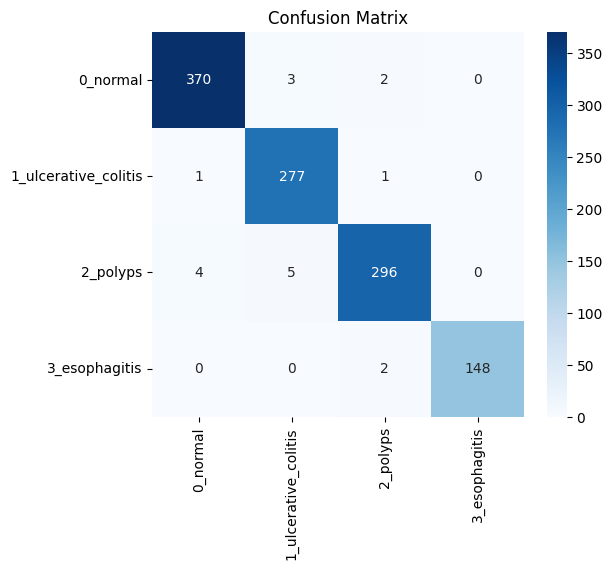

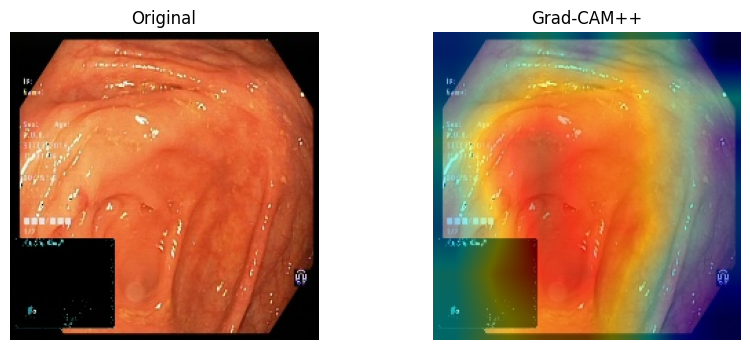

In [1]:
# ============================================================
# FULL EVALUATION + GRADCAM++ (MASK-AWARE)
# ============================================================

import os
import cv2
import torch
import timm
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from sklearn.preprocessing import label_binarize

from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD


# ============================================================
# CONFIG
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
BATCH_SIZE = 16
CLEAN_ROOT = r"D:\own_cleaned_mask"
CHECKPOINT_PATH = "best_reseff_fusion_masked.pth"


# ============================================================
# MASK-AWARE DATASET
# ============================================================

class MaskedImageFolder(Dataset):

    def __init__(self, root):
        self.samples = []
        self.classes = sorted([
            d for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d))
        ])
        self.class_to_idx = {c:i for i,c in enumerate(self.classes)}

        for cls in self.classes:
            cls_dir = os.path.join(root, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg','.jpeg','.png')) and not fname.endswith("_mask.png"):
                    img_path = os.path.join(cls_dir, fname)
                    base = os.path.splitext(fname)[0]
                    mask_path = os.path.join(cls_dir, f"{base}_mask.png")
                    if not os.path.exists(mask_path):
                        mask_path = None
                    self.samples.append((img_path, mask_path, self.class_to_idx[cls]))

        self.mean_tensor = torch.tensor(IMAGENET_DEFAULT_MEAN).view(3,1,1).float()

        self.transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
        ])

    def __len__(self):
        return len(self.samples)

    def _load_mask(self, path):
        if path is None:
            return np.ones((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

        m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if m is None:
            return np.ones((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

        m = cv2.resize(m, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        return (m > 127).astype(np.uint8)

    def __getitem__(self, idx):
        img_path, mask_path, label = self.samples[idx]

        pil = Image.open(img_path).convert("RGB")
        pil = self.transform(pil)

        img_tensor = transforms.ToTensor()(pil)

        mask_np = self._load_mask(mask_path)
        mask_tensor = torch.from_numpy(mask_np).unsqueeze(0).float()

        # replace ignored pixels with ImageNet mean
        img_tensor = img_tensor * mask_tensor + (1 - mask_tensor) * self.mean_tensor

        # normalize
        img_tensor = transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD)(img_tensor)

        return img_tensor, label


# ============================================================
# MODEL
# ============================================================

class ResEffFusion(nn.Module):

    def __init__(self, num_classes, eff_weight=0.7):
        super().__init__()

        self.eff_weight = eff_weight
        self.res_weight = 1 - eff_weight

        self.eff = timm.create_model("efficientnet_b4", pretrained=True, features_only=True)
        eff_dim = self.eff.feature_info[-1]['num_chs']

        self.res = timm.create_model("resnet50", pretrained=True, features_only=True)
        res_dim = self.res.feature_info[-1]['num_chs']

        self.eff_proj = nn.Conv2d(eff_dim, 1024, kernel_size=1)
        self.res_proj = nn.Conv2d(res_dim, 1024, kernel_size=1)

        self.bn = nn.BatchNorm2d(1024)
        self.relu = nn.ReLU(inplace=False)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(1024, num_classes)

    def forward(self, x):
        eff_feat = self.eff(x)[-1]
        res_feat = self.res(x)[-1]

        if eff_feat.shape[2:] != res_feat.shape[2:]:
            res_feat = nn.functional.interpolate(res_feat, size=eff_feat.shape[2:], mode="bilinear", align_corners=False)

        eff_feat = self.eff_proj(eff_feat)
        res_feat = self.res_proj(res_feat)

        fused = self.eff_weight * eff_feat + self.res_weight * res_feat
        fused = self.relu(self.bn(fused))

        pooled = self.pool(fused).flatten(1)
        return self.classifier(pooled)


# ============================================================
# GRADCAM++
# ============================================================

class GradCAMpp:

    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, inp, out):
        self.activations = out

    def backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(self, input_tensor, target_class):
        self.model.zero_grad()

        output = self.model(input_tensor)
        score = output[:, target_class]
        score.backward()

        activations = self.activations
        gradients = self.gradients

        grads_power_2 = gradients ** 2
        grads_power_3 = gradients ** 3

        sum_activations = torch.sum(activations, dim=(2,3), keepdim=True)

        alpha = grads_power_2 / (2 * grads_power_2 + sum_activations * grads_power_3 + 1e-8)

        positive_grad = torch.relu(gradients)
        weights = torch.sum(alpha * positive_grad, dim=(2,3))

        cam = torch.sum(weights.unsqueeze(-1).unsqueeze(-1) * activations, dim=1)
        cam = torch.relu(cam)

        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        return cv2.resize(cam, (IMG_SIZE, IMG_SIZE))


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    test_root = os.path.join(CLEAN_ROOT, "test") if os.path.exists(os.path.join(CLEAN_ROOT, "test")) else CLEAN_ROOT

    dataset = MaskedImageFolder(test_root)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

    CLASS_NAMES = dataset.classes
    NUM_CLASSES = len(CLASS_NAMES)

    model = ResEffFusion(NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
    model.eval()

    # ========================================================
    # EVALUATION
    # ========================================================

    y_true, y_pred, y_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)

            preds = probs.argmax(1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)

    print("\nAccuracy:", accuracy_score(y_true, y_pred))
    print("Macro F1:", f1_score(y_true, y_pred, average="macro"))

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES)
    plt.title("Confusion Matrix")
    plt.show()

    # ========================================================
    # GRADCAM++ ON FIRST IMAGE
    # ========================================================

    img_tensor, label = dataset[0]
    input_tensor = img_tensor.unsqueeze(0).to(DEVICE)

    pred = model(input_tensor).argmax(1).item()

    campp = GradCAMpp(model, model.bn)
    cam = campp.generate(input_tensor, pred)

    img_path = dataset.samples[0][0]
    img_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(img_rgb, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(img_rgb)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Grad-CAM++")
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()


Prediction:
Normal: 0.0001
Ulcerative Colitis: 0.9982
Polyps: 0.0005
Esophagitis: 0.0011

Predicted Class: Ulcerative Colitis


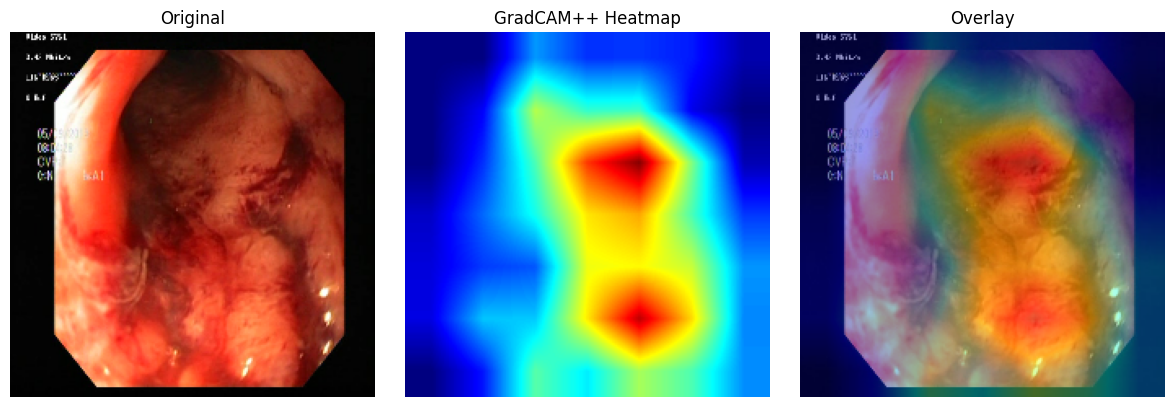

In [8]:
import os
import cv2
import torch
import timm
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD

# ============================================================
# CONFIG
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
CHECKPOINT_PATH = "best_reseff_fusion_masked.pth"

CLASS_NAMES = ['Normal','Ulcerative Colitis','Polyps','Esophagitis']

IMAGE_PATH = r"D:\Project\archive\train\1_ulcerative_colitis\584f1fa0-9bb9-49d3-b412-c42819d0a200_00001917.jpg"# change this

# ============================================================
# MODEL DEFINITION (same as training)
# ============================================================

class ResEffFusion(nn.Module):
    def __init__(self, num_classes, eff_weight=0.75):
        super().__init__()

        self.eff_weight = eff_weight
        self.res_weight = 1 - eff_weight

        self.eff = timm.create_model("efficientnet_b4", pretrained=False, features_only=True)
        eff_dim = self.eff.feature_info[-1]['num_chs']

        self.res = timm.create_model("resnet50", pretrained=False, features_only=True)
        res_dim = self.res.feature_info[-1]['num_chs']

        self.eff_proj = nn.Conv2d(eff_dim, 1024, 1)
        self.res_proj = nn.Conv2d(res_dim, 1024, 1)

        self.bn = nn.BatchNorm2d(1024)
        self.relu = nn.ReLU(inplace=False)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(1024, num_classes)

    def forward(self, x):
        eff = self.eff(x)[-1]
        res = self.res(x)[-1]

        if eff.shape[2:] != res.shape[2:]:
            res = nn.functional.interpolate(res, size=eff.shape[2:], mode="bilinear", align_corners=False)

        eff = self.eff_proj(eff)
        res = self.res_proj(res)

        fused = self.eff_weight * eff + self.res_weight * res
        fused = self.relu(self.bn(fused))

        pooled = self.pool(fused).flatten(1)
        return self.classifier(pooled)

# ============================================================
# GRADCAM++
# ============================================================

class GradCAMpp:

    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, inp, out):
        self.activations = out

    def backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(self, input_tensor, target_class):
        self.model.zero_grad()

        output = self.model(input_tensor)
        score = output[:, target_class]
        score.backward()

        activations = self.activations
        gradients = self.gradients

        grads_power_2 = gradients ** 2
        grads_power_3 = gradients ** 3

        sum_activations = torch.sum(activations, dim=(2,3), keepdim=True)

        alpha = grads_power_2 / (2 * grads_power_2 + sum_activations * grads_power_3 + 1e-8)

        positive_grad = torch.relu(gradients)
        weights = torch.sum(alpha * positive_grad, dim=(2,3))

        cam = torch.sum(weights.unsqueeze(-1).unsqueeze(-1) * activations, dim=1)
        cam = torch.relu(cam)

        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        return cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

# ============================================================
# LOAD MODEL
# ============================================================

model = ResEffFusion(len(CLASS_NAMES)).to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

# ============================================================
# LOAD IMAGE
# ============================================================

if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD)
])

input_tensor = transform(Image.fromarray(img_resized)).unsqueeze(0).to(DEVICE)

# ============================================================
# PREDICTION
# ============================================================

with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1).cpu().numpy().squeeze()
    pred_class = np.argmax(probs)

print("\nPrediction:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls}: {probs[i]:.4f}")

print("\nPredicted Class:", CLASS_NAMES[pred_class])

# ============================================================
# GRADCAM++
# ============================================================

campp = GradCAMpp(model, model.bn)  # hook into fusion BN
cam = campp.generate(input_tensor, pred_class)

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
overlay = cv2.addWeighted(img_resized, 0.6, heatmap, 0.4, 0)

# ============================================================
# DISPLAY
# ============================================================

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img_resized)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("GradCAM++ Heatmap")
plt.imshow(heatmap)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()